# Movement Time vs Coherence — supervisor revisions

Three figures, in order:

1. **Trim-cutoffs validation**: raw MT histogram per coherence bin, with vertical dashed lines at the 1st/99th percentile cutoffs and trials with `Sampling > 4.5 s` flagged in red. Lets us see *what* the trim is throwing away.
2. **Main figure** (replaces the old one): per-2P-session means as faint dots, bold line = mean of session means, error bars = **SEM across sessions** (n=23). Stalled trials (Sampling > 4.5 s) are excluded.
3. **Per-session grid**: one mini MT-vs-coherence plot per session for visual sanity-checking.

**SEM (Standard Error of the Mean)** = `std / sqrt(n)`. It tells you how precisely you've pinned down the *mean*, given your sample size — *not* how spread out the data is (that's SD). Computing SEM across **trials** (~5,000) makes the error bars look artificially tight because trials within a session aren't independent. SEM across **sessions** (n=23) is the honest number.


## 1. Load + flag stalled trials

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
DATA_FP = HERE / "paper_fast_slow-main" / "data" / "2p" / "df_all_by_epoch_df_f_filtered.pkl"

with open(DATA_FP, "rb") as f:
    df = pickle.load(f)

TRIAL_KEY = ["Name", "Date", "SessionNum", "TrialNumber"]

samp = (df[df.epoch == "Sampling"][TRIAL_KEY + ["epoch_time"]]
        .rename(columns={"epoch_time": "SamplingTime"}))

mv = df[df.epoch == "Movement to Lateral Port"].copy()
mv = mv[mv.ChoiceCorrect.notnull()]
mv["MT"]    = mv.epoch_time
mv["DVabs"] = mv.DV.abs()

mv = mv.merge(samp, on=TRIAL_KEY, how="left")
STALL_THRESH = 4.5
mv["stalled"] = mv.SamplingTime > STALL_THRESH

print(f"trials total : {len(mv):,}")
print(f"stalled (>{STALL_THRESH}s sampling): {mv.stalled.sum()} ({mv.stalled.mean()*100:.1f}%)")
print(f"unique mice  : {mv.Name.nunique()}")
print(f"unique 2P sessions: {mv[['Name','Date','SessionNum']].drop_duplicates().shape[0]}")


/sessions/ecstatic-youthful-feynman/tmp/ipykernel_8/2763190865.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


trials total : 5,408
stalled (>4.5s sampling): 71 (1.3%)
unique mice  : 6
unique 2P sessions: 23


## 2. Coherence bins and per-bin trim cutoffs

Three equal-width bins on `|DV|`: `[0, 1/3, 2/3, 1]`. Bin midpoints land at ~17%, 50%, 83% — matches the published figure. Trim cutoffs are computed per bin on **non-stalled** trials so the stalled tail doesn't pull them out.

In [2]:
BIN_EDGES = np.array([0.0, 1/3, 2/3, 1.01])
BIN_MIDS_PCT = (BIN_EDGES[:-1] + np.minimum(BIN_EDGES[1:], 1.0)) / 2 * 100
BIN_LABELS = [f"{lo*100:.0f}-{min(hi,1.0)*100:.0f}%"
              for lo, hi in zip(BIN_EDGES[:-1], BIN_EDGES[1:])]

mv["Bin"] = pd.cut(mv.DVabs, BIN_EDGES, include_lowest=True, labels=False).astype(int)

TRIM_LO, TRIM_HI = 1, 99
_clean = mv[~mv.stalled]
cutoffs = (_clean.groupby("Bin")["MT"]
           .agg(lo=lambda s: np.percentile(s, TRIM_LO),
                hi=lambda s: np.percentile(s, TRIM_HI)))
cutoffs


,lo,hi
Bin,,
0,0.232999,4.632693
1,0.214359,1.368705
2,0.232999,2.302367


## Figure 1 - Trim-cutoffs validation histogram

Log-y so the sparse tail (where the cutoffs live) is visible alongside the dense bulk.

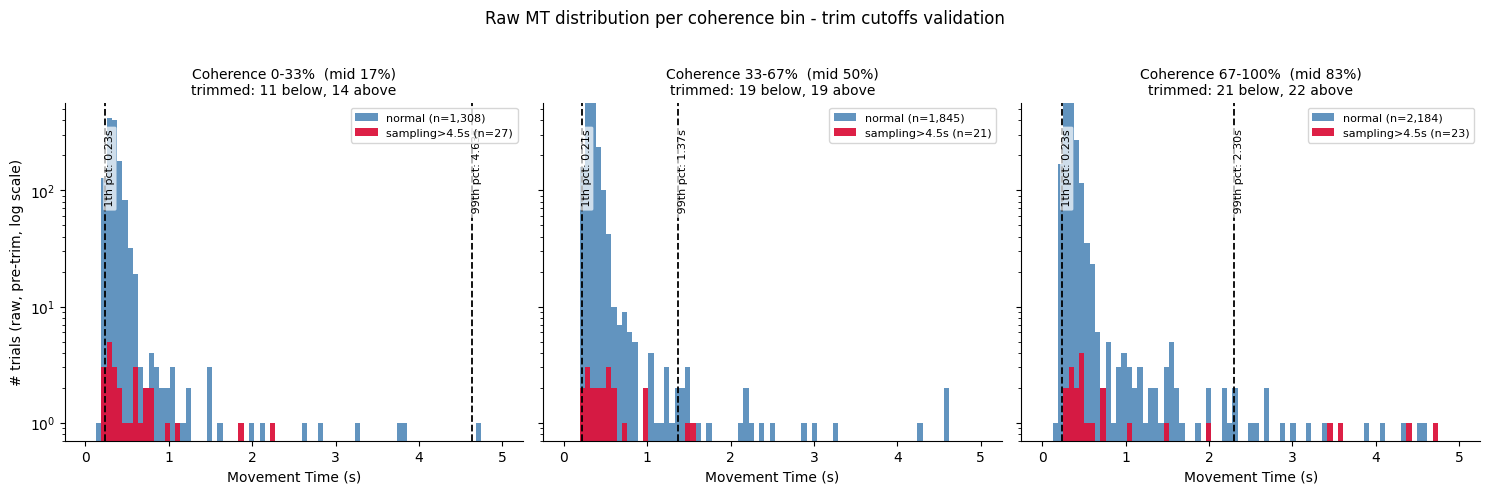

In [3]:
fig1, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
HIST_BINS = np.linspace(0, 5, 80)
for b, ax in enumerate(axes):
    sub = mv[mv.Bin == b]
    ok  = sub[~sub.stalled].MT.values
    bad = sub[ sub.stalled].MT.values

    ax.hist(ok,  bins=HIST_BINS, color="steelblue", alpha=0.85,
            label=f"normal (n={len(ok):,})")
    if len(bad):
        ax.hist(bad, bins=HIST_BINS, color="crimson", alpha=0.95,
                label=f"sampling>{STALL_THRESH}s (n={len(bad):,})")
    ax.set_yscale("log")
    ax.set_ylim(0.7, None)

    lo, hi = cutoffs.loc[b, "lo"], cutoffs.loc[b, "hi"]
    for x, lbl in [(lo, f"{TRIM_LO}th pct"), (hi, f"{TRIM_HI}th pct")]:
        ax.axvline(x, color="black", linestyle="--", linewidth=1.3)
        ax.text(x, ax.get_ylim()[1] * 0.6, f" {lbl}: {x:.2f}s",
                rotation=90, va="top", ha="left", fontsize=8, color="black",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

    n_clipped_lo = (ok < lo).sum()
    n_clipped_hi = (ok > hi).sum()
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)\n"
                 f"trimmed: {n_clipped_lo} below, {n_clipped_hi} above", fontsize=10)
    ax.set_xlabel("Movement Time (s)")
    if b == 0:
        ax.set_ylabel("# trials (raw, pre-trim, log scale)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, loc="upper right")

fig1.suptitle("Raw MT distribution per coherence bin - trim cutoffs validation",
              fontsize=12, y=1.02)
fig1.tight_layout()
fig1.savefig(HERE / "movement_time_histograms.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Drop stalled trials, then per-bin trim

In [4]:
mv_clean = mv[~mv.stalled].copy()

def _within_cutoffs(g):
    lo, hi = cutoffs.loc[g.name, "lo"], cutoffs.loc[g.name, "hi"]
    return g[(g.MT >= lo) & (g.MT <= hi)]

mv_trim = mv_clean.groupby("Bin", group_keys=False).apply(_within_cutoffs)

print(f"stalled dropped: {mv.stalled.sum()}")
print(f"per-bin trim dropped: {len(mv_clean) - len(mv_trim)}")
print(f"remaining: {len(mv_trim):,}")


stalled dropped: 71
per-bin trim dropped: 106
remaining: 5,231


/sessions/ecstatic-youthful-feynman/tmp/ipykernel_8/1144651699.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mv_trim = mv_clean.groupby("Bin", group_keys=False).apply(_within_cutoffs)


## Figure 2 - Main: session-level means, SEM across sessions

Each session contributes one mean MT per (bin x series). Faint dots = sessions, bold line = mean of session means, error bars = SEM across sessions.

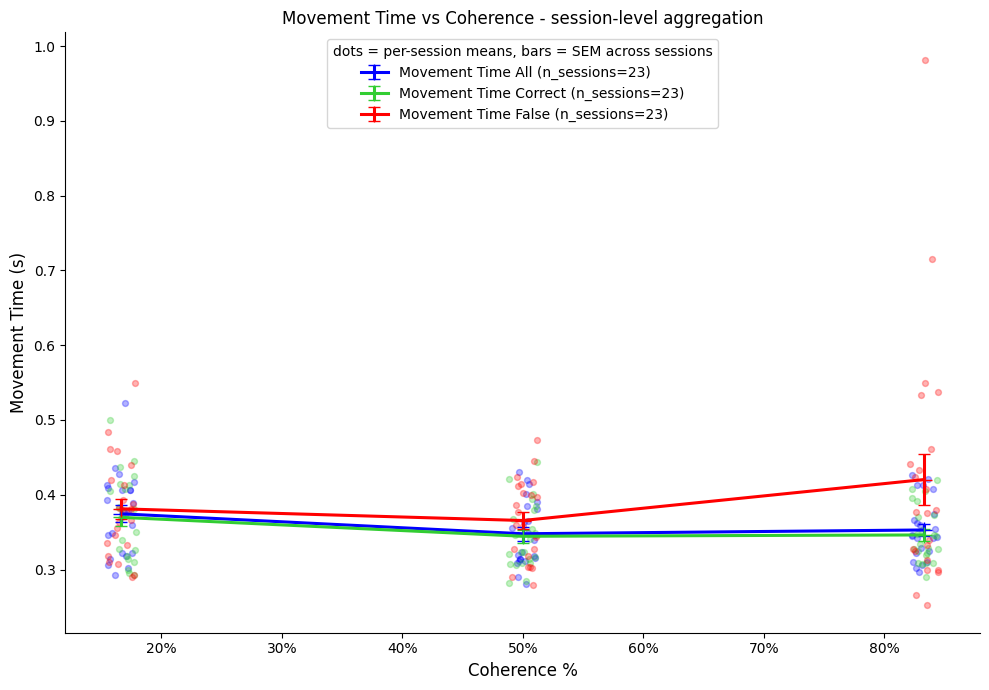

In [5]:
SERIES = {
    "All":     mv_trim,
    "Correct": mv_trim[mv_trim.ChoiceCorrect == 1],
    "False":   mv_trim[mv_trim.ChoiceCorrect == 0],
}
COLORS = {"All": "blue", "Correct": "limegreen", "False": "red"}
SESSION_KEY = ["Name", "Date", "SessionNum"]

def session_means(sub):
    return (sub.groupby(SESSION_KEY + ["Bin"])["MT"].mean()
               .reset_index().rename(columns={"MT": "MT_session_mean"}))

fig2, ax = plt.subplots(figsize=(10, 7))
summary_rows = []
rng = np.random.default_rng(0)
for name, sub in SERIES.items():
    sm = session_means(sub)
    g  = sm.groupby("Bin")["MT_session_mean"].agg(
            mean="mean",
            sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)),
            n_sessions="count")
    for b in g.index:
        ys = sm[sm.Bin == b]["MT_session_mean"].values
        xs = BIN_MIDS_PCT[b] + rng.uniform(-1.2, 1.2, size=len(ys))
        ax.scatter(xs, ys, s=18, color=COLORS[name], alpha=0.30, zorder=1)
    ax.errorbar(BIN_MIDS_PCT, g["mean"].values, yerr=g["sem"].values,
                fmt="-+", capsize=4, linewidth=2.2, markersize=12,
                color=COLORS[name],
                label=f"Movement Time {name} (n_sessions={int(g['n_sessions'].iloc[0])})",
                zorder=3)
    for b in g.index:
        summary_rows.append((name, int(b), BIN_MIDS_PCT[b],
                             g.loc[b, "mean"], g.loc[b, "sem"],
                             int(g.loc[b, "n_sessions"])))

ax.set_xlabel("Coherence %", fontsize=12)
ax.set_ylabel("Movement Time (s)", fontsize=12)
ax.set_xticks(np.arange(20, 90, 10))
ax.set_xticklabels([f"{t}%" for t in np.arange(20, 90, 10)])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper center", frameon=True, fontsize=10,
          title="dots = per-session means, bars = SEM across sessions")
ax.set_title("Movement Time vs Coherence - session-level aggregation", fontsize=12)
fig2.tight_layout()
fig2.savefig(HERE / "movement_time_vs_coherence.png", dpi=150)
plt.show()


## Figure 3 - Per-session sanity-check grid

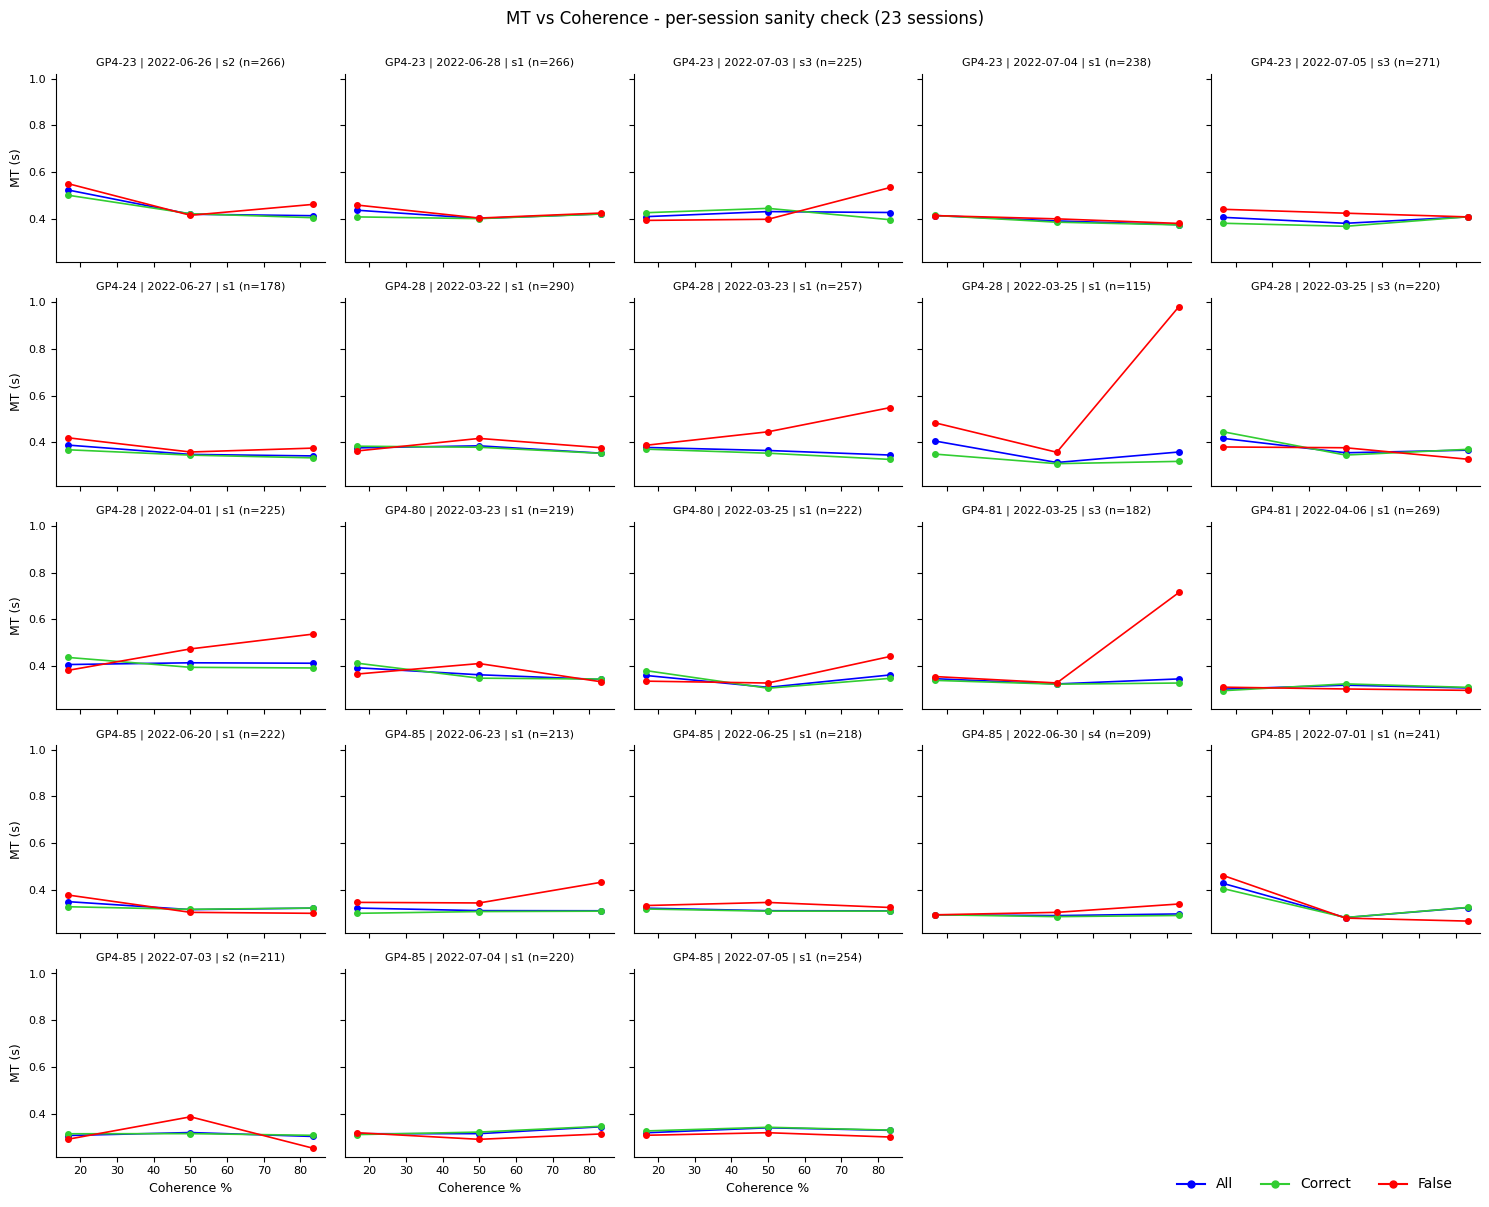

In [6]:
sessions = (mv_trim[SESSION_KEY].drop_duplicates()
            .sort_values(SESSION_KEY).reset_index(drop=True))
n_sess = len(sessions)
ncols = 5
nrows = int(np.ceil(n_sess / ncols))
fig3, axes3 = plt.subplots(nrows, ncols, figsize=(ncols*3.0, nrows*2.4),
                           sharex=True, sharey=True)
axes3 = np.atleast_2d(axes3)

for i, (_, srow) in enumerate(sessions.iterrows()):
    ax = axes3[i // ncols, i % ncols]
    sess_mask = ((mv_trim.Name == srow.Name)
                 & (mv_trim.Date == srow.Date)
                 & (mv_trim.SessionNum == srow.SessionNum))
    s_mv = mv_trim[sess_mask]
    for sname, scolor in COLORS.items():
        if sname == "All":     sub = s_mv
        elif sname == "Correct": sub = s_mv[s_mv.ChoiceCorrect == 1]
        else:                   sub = s_mv[s_mv.ChoiceCorrect == 0]
        m = sub.groupby("Bin")["MT"].mean()
        ax.plot(BIN_MIDS_PCT[m.index], m.values, "-o",
                color=scolor, markersize=4, linewidth=1.2)
    date_str = pd.to_datetime(srow.Date).strftime("%Y-%m-%d") if not isinstance(srow.Date, str) else str(srow.Date)
    ax.set_title(f"{srow.Name} | {date_str} | s{srow.SessionNum} (n={len(s_mv)})", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(n_sess, nrows * ncols):
    axes3[j // ncols, j % ncols].axis("off")
for ax in axes3[-1, :]:
    ax.set_xlabel("Coherence %", fontsize=9)
for ax in axes3[:, 0]:
    ax.set_ylabel("MT (s)", fontsize=9)

handles = [plt.Line2D([0], [0], color=c, marker="o", markersize=5, label=n)
           for n, c in COLORS.items()]
fig3.legend(handles=handles, loc="lower right", ncol=3, frameon=False,
            bbox_to_anchor=(0.98, 0.005))
fig3.suptitle(f"MT vs Coherence - per-session sanity check ({n_sess} sessions)",
              fontsize=12, y=1.00)
fig3.tight_layout()
fig3.savefig(HERE / "movement_time_per_session.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

In [7]:
print("Session-level summary (mean of session means +/- SEM across sessions):")
hdr = f"  {'series':<8} {'bin':>3} {'coh%':>5}  {'mean(s)':>8}  {'SEM(s)':>7}  {'n_sess':>6}"
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for name, b, mid, m, se, ns in summary_rows:
    print(f"  {name:<8} {b:>3} {mid:>4.1f}%  {m:>8.3f}  {se:>7.3f}  {ns:>6}")


Session-level summary (mean of session means +/- SEM across sessions):
  series   bin  coh%   mean(s)   SEM(s)  n_sess
  ---------------------------------------------
  All        0 16.7%     0.375    0.012      23
  All        1 50.0%     0.348    0.009      23
  All        2 83.3%     0.353    0.008      23
  Correct    0 16.7%     0.370    0.012      23
  Correct    1 50.0%     0.345    0.009      23
  Correct    2 83.3%     0.346    0.008      23
  False      0 16.7%     0.381    0.014      23
  False      1 50.0%     0.366    0.011      23
  False      2 83.3%     0.420    0.034      23
